![image info](https://user-images.githubusercontent.com/91945811/146929832-e78ff1f4-2739-41b1-acd3-019a39b6a42c.png)

### 📈 Aufgaben zur Zeitreihenanalyse mit Umsatzdaten

---

In [3]:
# Die benötigten Bibliotheken importieren
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose
from pandas.plotting import autocorrelation_plot
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error, mean_absolute_error

df_sales = pd.read_csv("df_sales.csv")
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1096 entries, 0 to 1095
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          1096 non-null   object 
 1   Sales         1096 non-null   float64
 2   Demand_Index  1096 non-null   float64
dtypes: float64(2), object(1)
memory usage: 25.8+ KB


In [4]:
# Datumsindex setzen
df_sales["Date"] = pd.to_datetime(df_sales["Date"])
df_sales.set_index("Date", inplace=True)
display(df_sales)

,Sales,Demand_Index
Date,,
2022-01-01,1050.677801,1.182651
2022-01-02,855.413220,1.149126
2022-01-03,1086.459662,1.188795
2022-01-04,1344.356771,1.233074
2022-01-05,812.533113,1.141764
...,...,...
2024-12-27,4909.847368,1.845239
2024-12-28,5134.430361,1.883798
2024-12-29,4926.874323,1.848162


## 📊 **1. Datenvisualisierung**
### **Aufgabe:**
Erstelle eine grafische Darstellung des Umsatzverlaufs über die Zeit und vergleiche ihn mit dem Nachfrageindex.

### **Hinweise:**
- Nutze `matplotlib.pyplot` zum Plotten der Daten.
- Verwende die `plot()`-Funktion, um den Umsatz darzustellen.
- Plotte den Nachfrageindex auf der gleichen Achse, aber skaliere ihn für eine bessere Vergleichbarkeit mit 2000.
- Vergiss nicht, Achsentitel, Legenden und eine sinnvolle Skalierung zu setzen.

---

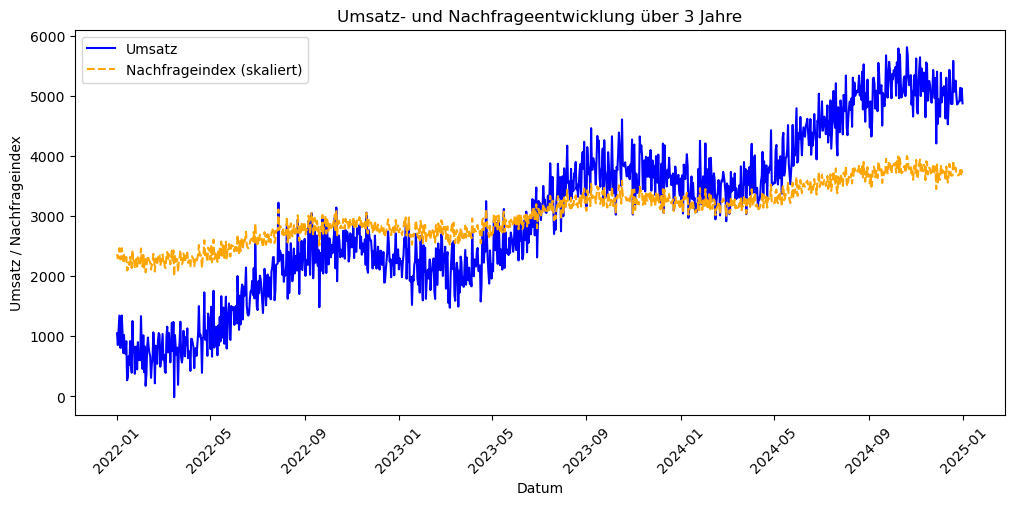

In [6]:
# 📌 1. Datenvisualisierung
plt.figure(figsize=(12, 5))
plt.plot(df_sales.index, df_sales["Sales"], label="Umsatz", color="blue")
plt.plot(df_sales.index, df_sales["Demand_Index"] * 2000, label="Nachfrageindex (skaliert)", color="orange", linestyle="dashed")
plt.xlabel("Datum")
plt.ylabel("Umsatz / Nachfrageindex")
plt.title("Umsatz- und Nachfrageentwicklung über 3 Jahre")
plt.legend()
plt.xticks(rotation=45)
plt.show()

## 🔄 **2. Saisonale Zerlegung (Decomposition)**
### **Aufgabe:**
Zerlege die Zeitreihe in ihre Bestandteile: **Trend, Saisonalität und Residuen** (Rauschen).

### **Hinweise:**
- Verwende `seasonal_decompose()` aus `statsmodels`.
- Wähle `model="additive"`, da der Umsatz eher additive saisonale Muster hat.
- Setze `period=365`, da sich saisonale Muster oft über ein Jahr erstrecken.
- Stelle die Ergebnisse in separaten Subplots dar.

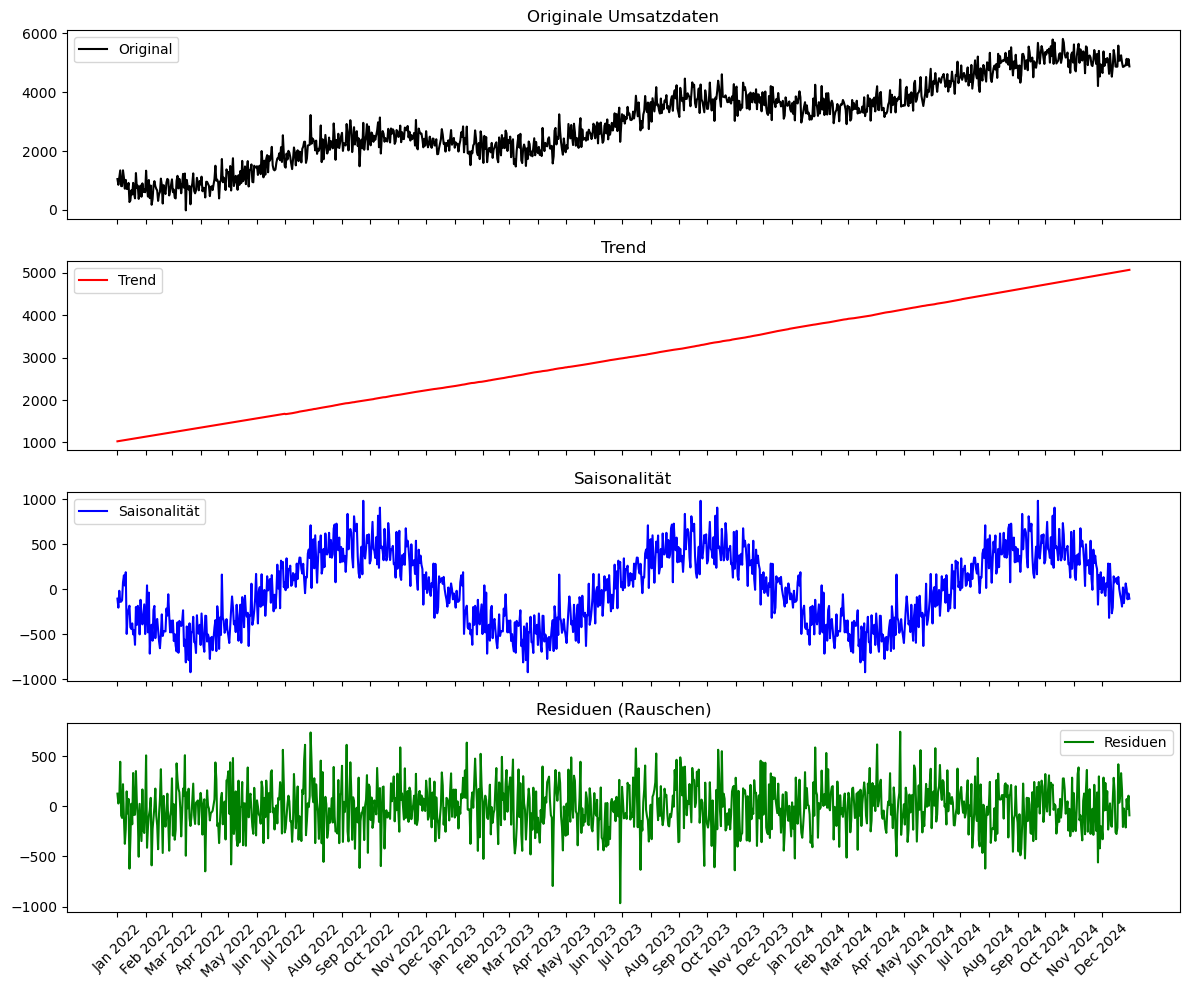

In [8]:

# 📌 2. Saisonale Zerlegung
result = seasonal_decompose(df_sales["Sales"], model="additive", period=365, extrapolate_trend="freq")

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
axes[0].plot(df_sales.index, df_sales["Sales"], label="Original", color="black")
axes[0].set_title("Originale Umsatzdaten")
axes[0].legend()

axes[1].plot(df_sales.index, result.trend, label="Trend", color="red")
axes[1].set_title("Trend")
axes[1].legend()

axes[2].plot(df_sales.index, result.seasonal, label="Saisonalität", color="blue")
axes[2].set_title("Saisonalität")
axes[2].legend()

axes[3].plot(df_sales.index, result.resid, label="Residuen", color="green")
axes[3].set_title("Residuen (Rauschen)")
axes[3].legend()

# X-Achsen-Ticks setzen: Monatliche Labels
xticks = pd.date_range(start=df_sales.index.min(), end=df_sales.index.max(), freq="MS")
axes[3].set_xticks(xticks)
axes[3].set_xticklabels(xticks.strftime("%b %Y"), rotation=45)
plt.tight_layout()
plt.show()


---
## 🔄 **3. Autokorrelationsanalyse**
### **Aufgabe:**
Untersuche, ob vergangene Umsatzwerte einen Einfluss auf die aktuellen Werte haben.

### **Hinweise:**
- Nutze `autocorrelation_plot()` aus `pandas.plotting`, um die Autokorrelation zu visualisieren.
- Achte auf **wiederkehrende Peaks**, die auf saisonale Muster hinweisen könnten.
- Wenn die Autokorrelation langsam abnimmt, deutet dies auf einen **anhaltenden Trend** hin.

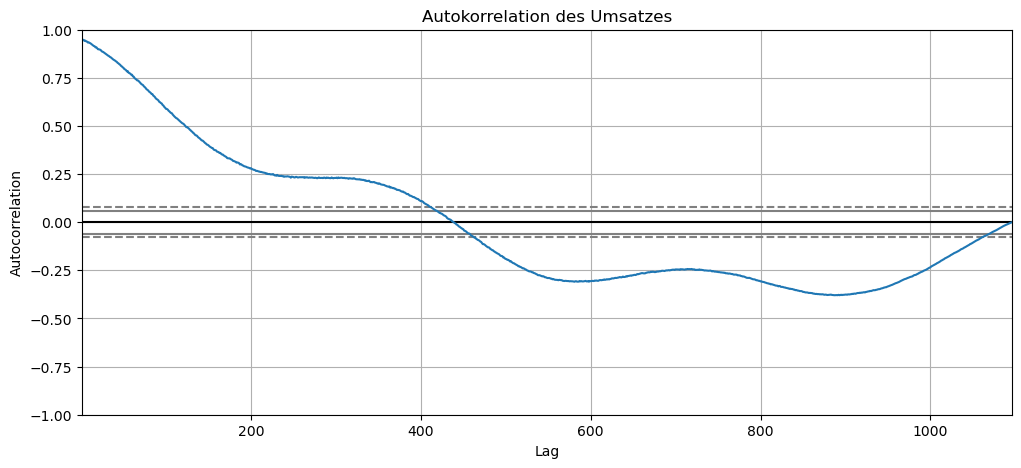

In [10]:
# 📌 3. Autokorrelationsanalyse
plt.figure(figsize=(12, 5))
autocorrelation_plot(df_sales["Sales"])
plt.title("Autokorrelation des Umsatzes")
plt.show()


### **📌 Interpretation der Autokorrelationsfunktion (ACF) für den Umsatz**  

Das **Autokorrelationsdiagramm (ACF-Plot)** zeigt, wie stark die Umsatzwerte mit ihren eigenen vergangenen Werten korrelieren.  

#### **1️⃣ Langsamer Abfall der Autokorrelation**
- Die Autokorrelationswerte **nehmen langsam über die Zeit ab**.
- Dies deutet darauf hin, dass der Umsatz einen **anhaltenden Trend** hat.
- Es gibt also eine **langfristige Abhängigkeit** zwischen den Umsatzwerten (Vergangene Werte beeinflussen stark die Zukunft).

#### **2️⃣ Negative Korrelation nach ca. 400-600 Tagen**
- Die Autokorrelation fällt unter **Null** bei ca. **400-600 Tagen**.
- Dies könnte darauf hinweisen, dass der Umsatz nach ca. **1-1,5 Jahren eine gegenläufige Bewegung hat**.
- Das könnte ein Hinweis auf **saisonale Effekte oder wirtschaftliche Zyklen** sein.

#### **3️⃣ Wiederanstieg gegen Ende**
- Die Autokorrelationswerte steigen bei hohen Lags (900-1000 Tage) wieder leicht an.
- Dies könnte bedeuten, dass es eine **gewisse Wiederholung nach ca. 3 Jahren gibt**.

---

### **📌 Fazit:**
✅ **Starke Korrelation mit vergangenen Werten** → Umsatz zeigt einen klaren **Trend**.  
✅ **Langfristige zyklische Muster (~1-1,5 Jahre)** → Mögliche wirtschaftliche oder saisonale Schwankungen.  
✅ **Leichter Wiederanstieg nach ~3 Jahren** → Mögliche wiederkehrende Muster.  


---
## 🎨 **4. Naiver Forecast**
### **Aufgabe:**
Erstelle eine einfache Umsatzprognose, indem du den letzten bekannten Wert für alle zukünftigen Tage verwendest.

### **Hinweise:**
- Teile die Daten in einen **Trainingssatz** (Vergangenheit) und einen **Testdatensatz** (zukünftige Werte).
- Nutze `numpy.repeat()`, um den letzten bekannten Wert für alle Vorhersagen zu wiederholen.
- Vergleiche die Prognose mit den echten Testwerten.

In [13]:
# 📌 4. Naiver Forecast
train = df_sales.iloc[:-30]
test = df_sales.iloc[-30:]
naive_forecast = np.repeat(train["Sales"].iloc[-1], len(test))


---
## 🌟 **5. Seasonal Naive Forecast**
### **Aufgabe:**
Nutze saisonale Muster, um die Vorhersage zu verbessern: Verwende den Umsatz vom gleichen Tag des Vorjahres.

### **Hinweise:**
- Verschiebe die Zeitreihe um 365 Tage mit `shift(365)`, um den Vorjahreswert als Prognose zu nehmen.
- Stelle die Ergebnisse grafisch dar und vergleiche sie mit dem naiven Forecast.

In [15]:

# 📌 5. Seasonal Naive Forecast (Umsatz vom gleichen Tag des Vorjahres)
seasonal_naive_forecast = train["Sales"].shift(365).iloc[-30:].values

---

## 📈 **6. Holt-Winters Modell (Exponentielle Glättung)**
### **Aufgabe:**
Erstelle eine Umsatzprognose mit dem **Holt-Winters Modell**, das sowohl **Trend als auch Saisonalität** berücksichtigt.

### **Hinweise:**
- Verwende `ExponentialSmoothing()` aus `statsmodels`.
- Setze `trend="add"` und `seasonal="add"`.
- Nutze `seasonal_periods=365` für eine jährliche Saisonalität.
- Plotte die Ergebnisse zusammen mit den echten Werten.

In [17]:

# 📌 6. Holt-Winters Modell
model = ExponentialSmoothing(train["Sales"], trend="add", seasonal="add", seasonal_periods=365)
fitted_model = model.fit()
holt_forecast = fitted_model.forecast(steps=30)

C:\Users\ahmed\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


---

## 📊 **7. Prognosen vergleichen**
### **Aufgabe:**
Erstelle eine Grafik, die den **Naiven Forecast, Seasonal Naive Forecast und Holt-Winters Modell** vergleicht.

### **Hinweise:**
- Zeichne alle Prognosen und die echten Werte in einem einzigen Diagramm.
- Nutze verschiedene Farben und Linienstile, um die Methoden zu unterscheiden.
- Achte darauf, dass die x-Achse sinnvoll skaliert ist.

---

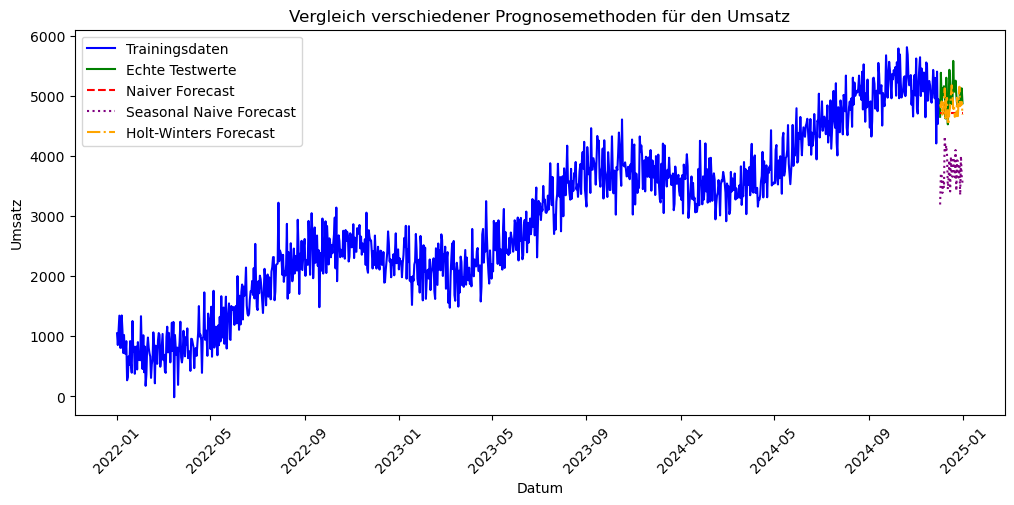

In [19]:
# 📌 7. Prognosen visualisieren
plt.figure(figsize=(12, 5))
plt.plot(train.index, train["Sales"], label="Trainingsdaten", color="blue")
plt.plot(test.index, test["Sales"], label="Echte Testwerte", color="green")
plt.plot(test.index, naive_forecast, label="Naiver Forecast", linestyle="dashed", color="red")
plt.plot(test.index, seasonal_naive_forecast, label="Seasonal Naive Forecast", linestyle="dotted", color="purple")
plt.plot(test.index, holt_forecast, label="Holt-Winters Forecast", linestyle="dashdot", color="orange")
plt.legend()
plt.title("Vergleich verschiedener Prognosemethoden für den Umsatz")
plt.xlabel("Datum")
plt.ylabel("Umsatz")
plt.xticks(rotation=45)
plt.show()

## 🔢 **8. Prognosequalität messen**
### **Aufgabe:**
Berechne Fehlermetriken (**MSE, RMSE, MAE**) für die verschiedenen Vorhersagemodelle.
Welche der Methoden funktioniert am besten? Begründe deine Antwort anhand der Fehlermetriken.


### **Hinweise:**
- Verwende `mean_squared_error()` und `mean_absolute_error()` aus `sklearn.metrics`.
- Der **MSE (Mean Squared Error)** bewertet quadratische Fehler (bestraft große Fehler stärker).
- Der **RMSE (Root Mean Squared Error)** ist die Wurzel des MSE und hat dieselbe Einheit wie die Umsatzwerte.
- Der **MAE (Mean Absolute Error)** gibt die durchschnittliche absolute Abweichung an.
- Vergleiche die Fehlerwerte der drei Methoden und erkläre, welche Methode die genaueste Prognose liefert.

---

In [21]:
# 📌 8. Fehlermetriken berechnen
mse_naive = mean_squared_error(test["Sales"], naive_forecast)
rmse_naive = np.sqrt(mse_naive)
mae_naive = mean_absolute_error(test["Sales"], naive_forecast)

mse_seasonal = mean_squared_error(test["Sales"], seasonal_naive_forecast)
rmse_seasonal = np.sqrt(mse_seasonal)
mae_seasonal = mean_absolute_error(test["Sales"], seasonal_naive_forecast)

mse_holt = mean_squared_error(test["Sales"], holt_forecast)
rmse_holt = np.sqrt(mse_holt)
mae_holt = mean_absolute_error(test["Sales"], holt_forecast)

# Ergebnisse anzeigen
error_results = pd.DataFrame({
    "mse": [mse_naive, mse_seasonal, mse_holt],
    "rmse": [rmse_naive, rmse_seasonal, rmse_holt],
    "mae": [mae_naive, mae_seasonal, mae_holt]
}, index=["Naiver Forecast", "Seasonal Naive", "Holt-Winters"])

display(error_results)


,mse,rmse,mae
Naiver Forecast,1.446480e+05,380.326181,321.695783
Seasonal Naive,1.711513e+06,1308.247918,1267.125232
Holt-Winters,1.121538e+05,334.893719,271.483844


Holt Winters hat den geringsten Fehler.